In [ ]:
!wget -O banglaclip_model_epoch_10.pth https://huggingface.co/Mansuba/BanglaCLIP13/resolve/main/banglaclip_model_epoch_10.pth



--2025-02-05 08:56:32--  https://huggingface.co/Mansuba/BanglaCLIP13/resolve/main/banglaclip_model_epoch_10.pth
Resolving huggingface.co (huggingface.co)... 13.35.202.97, 13.35.202.34, 13.35.202.40, ...
Connecting to huggingface.co (huggingface.co)|13.35.202.97|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cdn-lfs-us-1.hf.co/repos/2a/ad/2aadee49f0f0c86b7b267a72f0937b06e9c98f694b60f9d09a1698caad62340d/f25c01d0773579e603903fefc52f721337cf92cbcbfb4ab6e48d2c858c8cbc3f?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27banglaclip_model_epoch_10.pth%3B+filename%3D%22banglaclip_model_epoch_10.pth%22%3B&Expires=1738749392&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTczODc0OTM5Mn19LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy11cy0xLmhmLmNvL3JlcG9zLzJhL2FkLzJhYWRlZTQ5ZjBmMGM4NmI3YjI2N2E3MmYwOTM3YjA2ZTljOThmNjk0YjYwZjlkMDlhMTY5OGNhYWQ2MjM0MGQvZjI1YzAxZDA3NzM1NzllNjAzOTAzZmVmYzUyZjcyMTMzN2NmOTJjYmNiZmI0YWI2ZTQ

In [ ]:
import torch
from transformers import CLIPModel, CLIPProcessor, AutoTokenizer, MarianMTModel, MarianTokenizer
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler
from typing import List, Tuple, Optional, Dict, Any
from pathlib import Path
import logging
from dataclasses import dataclass
import gc

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

@dataclass
class GenerationConfig:
    num_images: int = 1
    num_inference_steps: int = 50
    guidance_scale: float = 7.5
    seed: Optional[int] = None

class ModelCache:
    def __init__(self, cache_dir: Path):
        self.cache_dir = cache_dir
        self.cache_dir.mkdir(parents=True, exist_ok=True)

    def load_model(self, model_id: str, load_func: callable, cache_name: str) -> Any:
        try:
            logger.info(f"Loading {cache_name}")
            return load_func(model_id)
        except Exception as e:
            logger.error(f"Error loading model {cache_name}: {str(e)}")
            raise

class EnhancedBanglaSDGenerator:
    def __init__(
        self,
        banglaclip_weights_path: str,
        cache_dir: str,
        device: Optional[torch.device] = None
    ):
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        logger.info(f"Using device: {self.device}")

        self.cache = ModelCache(Path(cache_dir))
        self._initialize_models(banglaclip_weights_path)
        self._load_context_data()

    def _initialize_models(self, banglaclip_weights_path: str):
        try:
            # Initialize translation models
            self.bn2en_model_name = "Helsinki-NLP/opus-mt-bn-en"
            self.translator = self.cache.load_model(
                self.bn2en_model_name,
                MarianMTModel.from_pretrained,
                "translator"
            ).to(self.device)
            self.trans_tokenizer = MarianTokenizer.from_pretrained(self.bn2en_model_name)

            # Initialize CLIP models
            self.clip_model_name = "openai/clip-vit-base-patch32"
            self.bangla_text_model = "csebuetnlp/banglabert"
            self.banglaclip_model = self._load_banglaclip_model(banglaclip_weights_path)
            self.processor = CLIPProcessor.from_pretrained(self.clip_model_name)
            self.tokenizer = AutoTokenizer.from_pretrained(self.bangla_text_model)

            # Initialize Stable Diffusion
            self._initialize_stable_diffusion()

        except Exception as e:
            logger.error(f"Error initializing models: {str(e)}")
            raise RuntimeError(f"Failed to initialize models: {str(e)}")

    def _initialize_stable_diffusion(self):
        """Initialize Stable Diffusion pipeline with optimized settings."""
        self.pipe = self.cache.load_model(
            "runwayml/stable-diffusion-v1-5",
            lambda model_id: StableDiffusionPipeline.from_pretrained(
                model_id,
                torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
                safety_checker=None
            ),
            "stable_diffusion"
        )

        self.pipe.scheduler = DPMSolverMultistepScheduler.from_config(
            self.pipe.scheduler.config,
            use_karras_sigmas=True,
            algorithm_type="dpmsolver++"
        )
        self.pipe = self.pipe.to(self.device)

        # Memory optimization
        self.pipe.enable_attention_slicing()
        if torch.cuda.is_available():
            self.pipe.enable_sequential_cpu_offload()

    def _load_banglaclip_model(self, weights_path: str) -> CLIPModel:
        try:
            if not Path(weights_path).exists():
                raise FileNotFoundError(f"BanglaCLIP weights not found at {weights_path}")

            clip_model = CLIPModel.from_pretrained(self.clip_model_name)
            state_dict = torch.load(weights_path, map_location=self.device)

            cleaned_state_dict = {
                k.replace('module.', '').replace('clip.', ''): v
                for k, v in state_dict.items()
                if k.replace('module.', '').replace('clip.', '').startswith(('text_model.', 'vision_model.'))
            }

            clip_model.load_state_dict(cleaned_state_dict, strict=False)
            return clip_model.to(self.device)

        except Exception as e:
            logger.error(f"Failed to load BanglaCLIP model: {str(e)}")
            raise

    def _load_context_data(self):
        """Load location and scene context data."""
        self.location_contexts = {
            'কক্সবাজার': 'Cox\'s Bazar beach, longest natural sea beach in the world, sandy beach',
            'সেন্টমার্টিন': 'Saint Martin\'s Island, coral island, tropical paradise',
            'সুন্দরবন': 'Sundarbans mangrove forest, Bengal tigers, riverine forest'
        }

        self.scene_contexts = {
            'সৈকত': 'beach, seaside, waves, sandy shore, ocean view',
            'সমুদ্র': 'ocean, sea waves, deep blue water, horizon',
            'পাহাড়': 'mountains, hills, valleys, scenic landscape'
        }

    def _translate_text(self, bangla_text: str) -> str:
        """Translate Bangla text to English."""
        inputs = self.trans_tokenizer(bangla_text, return_tensors="pt", padding=True)
        inputs = {k: v.to(self.device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = self.translator.generate(**inputs)

        translated = self.trans_tokenizer.decode(outputs[0], skip_special_tokens=True)
        return translated

    def generate_image(
        self,
        bangla_text: str,
        config: Optional[GenerationConfig] = None
    ) -> Tuple[List[Any], str]:
        if not bangla_text.strip():
            raise ValueError("Empty input text")

        config = config or GenerationConfig()

        try:
            if config.seed is not None:
                torch.manual_seed(config.seed)

            enhanced_prompt = self._enhance_prompt(bangla_text)
            negative_prompt = self._get_negative_prompt()

            with torch.autocast(self.device.type):
                result = self.pipe(
                    prompt=enhanced_prompt,
                    negative_prompt=negative_prompt,
                    num_images_per_prompt=config.num_images,
                    num_inference_steps=config.num_inference_steps,
                    guidance_scale=config.guidance_scale
                )

            return result.images, enhanced_prompt

        except Exception as e:
            logger.error(f"Error during image generation: {str(e)}")
            raise

    def _enhance_prompt(self, bangla_text: str) -> str:
        """Enhance prompt with context and style information."""
        translated_text = self._translate_text(bangla_text)

        # Gather contexts
        contexts = []
        contexts.extend(context for loc, context in self.location_contexts.items() if loc in bangla_text)
        contexts.extend(context for scene, context in self.scene_contexts.items() if scene in bangla_text)

        # Add photo style
        photo_style = [
            "professional photography",
            "high resolution",
            "4k",
            "detailed",
            "realistic",
            "beautiful composition"
        ]

        # Combine all parts
        all_parts = [translated_text] + contexts + photo_style
        return ", ".join(dict.fromkeys(all_parts))

    def _get_negative_prompt(self) -> str:
        return (
            "blurry, low quality, pixelated, cartoon, anime, illustration, "
            "painting, drawing, artificial, fake, oversaturated, undersaturated"
        )

    def cleanup(self):
        """Clean up GPU memory"""
        if hasattr(self, 'pipe'):
            del self.pipe
        if hasattr(self, 'banglaclip_model'):
            del self.banglaclip_model
        if hasattr(self, 'translator'):
            del self.translator
        torch.cuda.empty_cache()
        gc.collect()

def main():
    # Example usage
    generator = EnhancedBanglaSDGenerator(
        banglaclip_weights_path="banglaclip_model_epoch_10.pth",
        cache_dir="model_cache"
    )

    # Example configuration
    config = GenerationConfig(
        num_images=1,
        num_inference_steps=50,
        guidance_scale=7.5,
        seed=42  # Optional: set to None for random seed
    )

    try:
        # Generate image from Bangla text
        bangla_text = "সুন্দরবনের মধ্যে একটি বাঘ"  # Example: "A tiger in the Sundarbans"
        images, prompt = generator.generate_image(bangla_text, config)

        # Save the generated images
        for i, image in enumerate(images):
            image.save(f"generated_image_{i}.png")

        print(f"Generated images saved with prompt: {prompt}")

    except Exception as e:
        print(f"Error generating image: {str(e)}")

    finally:
        # Clean up resources
        generator.cleanup()

if __name__ == "__main__":
    main()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/309M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

...

unet/config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/50 [00:00<?, ?it/s]

Generated images saved with prompt: A tiger in the Sundarbans, Sundarbans mangrove forest, Bengal tigers, riverine forest, professional photography, high resolution, 4k, detailed, realistic, beautiful composition


<ipython-input-2-848f051d46ac>:106: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weights_path, map_location=self.device)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

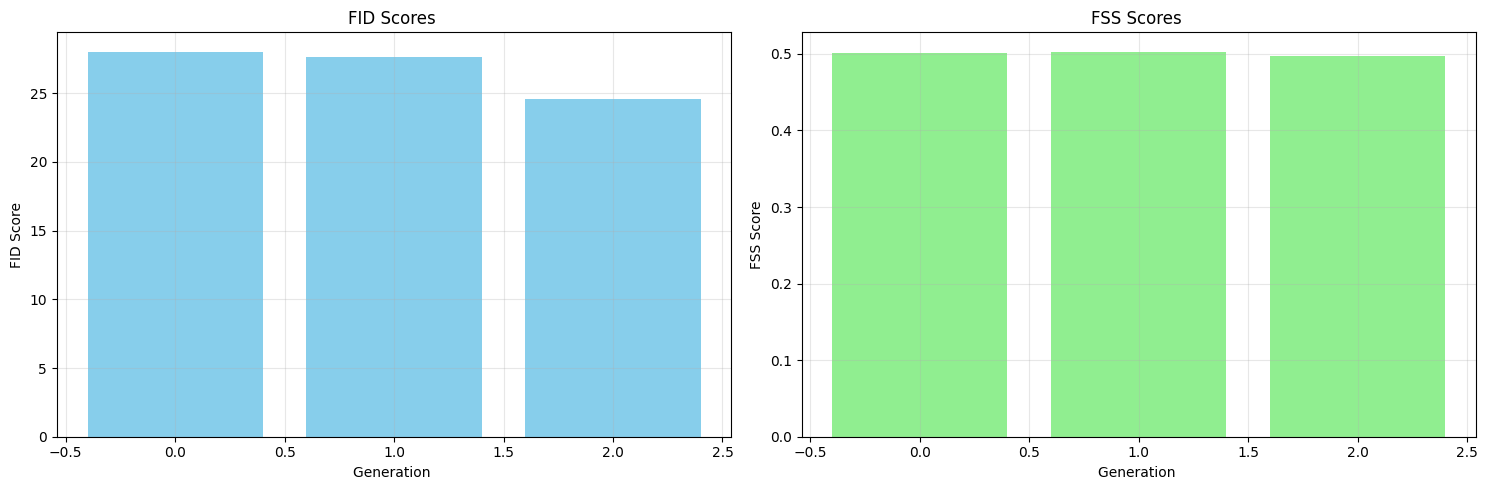

Generated images with prompt: A tiger in the Sundarbans, Sundarbans mangrove forest, Bengal tigers, riverine forest, professional photography, high resolution, 4k, detailed, realistic, beautiful composition
FID Scores: [28.036151885986328, 27.649654388427734, 24.565351486206055]
FSS Scores: [0.50063914, 0.50303775, 0.49673158]


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from transformers import CLIPModel
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import sqrtm
import logging

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

class FeatureSemanticSimilarity(nn.Module):
    def __init__(self, feature_dim):
        super(FeatureSemanticSimilarity, self).__init__()
        self.fc1 = nn.Linear(feature_dim, feature_dim // 2)
        self.fc2 = nn.Linear(feature_dim // 2, 1)
        self.relu = nn.ReLU()

    def forward(self, features1, features2):
        combined = torch.cat((features1, features2), dim=1)
        x = self.relu(self.fc1(combined))
        similarity = torch.sigmoid(self.fc2(x))
        return similarity.squeeze()

class MetricsEvaluator:
    def __init__(self, generator, device=None):
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.generator = generator

        # Initialize Feature Semantic Similarity module
        self.fss_module = FeatureSemanticSimilarity(feature_dim=512*2).to(self.device)

        # Initialize image transformation
        self.image_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def _safe_fid_calculation(self, mu1, sigma1, mu2, sigma2):
        """Robust FID calculation with error handling"""
        try:
            mu1 = np.atleast_2d(mu1.flatten())
            mu2 = np.atleast_2d(mu2.flatten())
            sigma1 = np.atleast_2d(sigma1)
            sigma2 = np.atleast_2d(sigma2)

            sigma1 = (sigma1 + sigma1.T) / 2
            sigma2 = (sigma2 + sigma2.T) / 2

            try:
                covmean = sqrtm(sigma1.dot(sigma2))
            except:
                covmean = np.eye(sigma1.shape[0])

            if np.iscomplexobj(covmean):
                covmean = covmean.real

            diff = mu1.flatten() - mu2.flatten()
            fid = np.sum(diff**2) + np.trace(sigma1 + sigma2 - 2 * covmean)

            return float(fid)
        except Exception as e:
            logger.error(f"FID calculation error: {e}")
            return float('inf')

    def _compute_statistics(self, features):
        features = np.atleast_2d(features)
        mu = np.mean(features, axis=0)
        sigma = np.cov(features, rowvar=False) if features.shape[0] > 1 else np.eye(features.shape[1])
        return mu, sigma

    def extract_features(self, image):
        """Extract features using BanglaCLIP model"""
        image_tensor = self.image_transform(image).unsqueeze(0).to(self.device)
        with torch.no_grad():
            features = self.generator.banglaclip_model.get_image_features(image_tensor)
            return features.cpu().numpy()

    def evaluate_generations(self, reference_image_path, bangla_text, num_generations=3):
        """Generate and evaluate images with metrics"""
        # Load reference image
        reference_image = Image.open(reference_image_path)
        ref_features = self.extract_features(reference_image)

        results = {
            'fid_scores': [],
            'fss_scores': [],
            'generated_images': [],
            'prompt': None
        }

        # Generate multiple images and calculate metrics
        config = GenerationConfig(num_images=1, num_inference_steps=50)

        for _ in range(num_generations):
            images, prompt = self.generator.generate_image(bangla_text, config)
            results['prompt'] = prompt

            for image in images:
                results['generated_images'].append(image)
                gen_features = self.extract_features(image)

                # Calculate FID
                fid_score = self._safe_fid_calculation(
                    *self._compute_statistics(ref_features),
                    *self._compute_statistics(gen_features)
                )
                results['fid_scores'].append(fid_score)

                # Calculate FSS
                fss_score = self.calculate_fss(ref_features, gen_features)
                results['fss_scores'].append(fss_score)

        # Plot metrics
        self._plot_metrics(results)
        return results

    def calculate_fss(self, ref_features, gen_features):
        """Calculate Feature Semantic Similarity score"""
        ref_tensor = torch.tensor(ref_features, dtype=torch.float32).to(self.device)
        gen_tensor = torch.tensor(gen_features, dtype=torch.float32).to(self.device)

        with torch.no_grad():
            similarities = []
            for ref_feat in ref_tensor:
                for gen_feat in gen_tensor:
                    similarity = self.fss_module(ref_feat.unsqueeze(0), gen_feat.unsqueeze(0)).cpu().numpy()
                    similarities.append(similarity)

        return np.mean(similarities)

    def _plot_metrics(self, results):
        """Plot FID and FSS metrics"""
        plt.figure(figsize=(15, 5))

        # Plot FID scores
        plt.subplot(1, 2, 1)
        plt.bar(range(len(results['fid_scores'])), results['fid_scores'], color='skyblue')
        plt.title('FID Scores ')
        plt.xlabel('Generation ')
        plt.ylabel('FID Score')
        plt.grid(True, alpha=0.3)

        # Plot FSS scores
        plt.subplot(1, 2, 2)
        plt.bar(range(len(results['fss_scores'])), results['fss_scores'], color='lightgreen')
        plt.title('FSS Scores ')
        plt.xlabel('Generation ')
        plt.ylabel('FSS Score')
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

def main():
    # Initialize generator
    generator = EnhancedBanglaSDGenerator(
        banglaclip_weights_path="banglaclip_model_epoch_10.pth",
        cache_dir="model_cache"
    )

    # Initialize evaluator
    evaluator = MetricsEvaluator(generator)

    try:
        # Generate and evaluate images
        bangla_text = "সুন্দরবনের মধ্যে একটি বাঘ"  # "A tiger in the Sundarbans"
        results = evaluator.evaluate_generations(
            reference_image_path="RoyalBengalTiger-1024x576.jpg",
            bangla_text=bangla_text,
            num_generations=3
        )

        # Print results
        print(f"Generated images with prompt: {results['prompt']}")
        print(f"FID Scores: {results['fid_scores']}")
        print(f"FSS Scores: {results['fss_scores']}")

        # Save generated images
        for i, image in enumerate(results['generated_images']):
            image.save(f"generated_tiger_{i}.png")

    except Exception as e:
        print(f"Error: {str(e)}")

    finally:
        # Clean up
        generator.cleanup()

if __name__ == "__main__":
    main()